# ДЗ 7. Класифікація спаму: BoW, TF-IDF і попередньо навчені ембедінги

Датасет Email Spam Detection (Kaggle). Порівнюю три способи перетворити текст у вектор
(лічильники слів, TF-IDF, усереднені GloVe)

In [ ]:
import importlib.util, subprocess, sys

for pkg in ["kagglehub", "gensim", "nltk", "spacy"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)
if importlib.util.find_spec("en_core_web_sm") is None:
    subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm", "-q"], check=True)

In [2]:
import re
import html
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
import nltk
from nltk.corpus import stopwords
import spacy
import gensim.downloader as api
from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score, recall_score,
                             f1_score, roc_curve, confusion_matrix)

SEED = 42
np.random.seed(SEED)
nltk.download("stopwords", quiet=True)

COLORS = {"ham": "#2a78d6", "spam": "#eb6834"}
MODEL_COLORS = ["#2a78d6", "#eb6834", "#1baf7a"]

## Дані

Файл spam.csv у кодуванні latin-1, корисні тільки перші дві колонки (мітка і текст), ще три
порожні.

In [3]:
path = kagglehub.dataset_download("shantanudhakadd/email-spam-detection-dataset-classification")
print("Path to dataset files:", path)

df = pd.read_csv(f"{path}/spam.csv", encoding="latin-1", usecols=[0, 1])
df.columns = ["label", "text"]
print("до видалення дублікатів:", df.shape)
df = df.drop_duplicates(subset="text").reset_index(drop=True)
print("після:", df.shape)
df.head()

Path to dataset files: /Users/andyparshyn/.cache/kagglehub/datasets/shantanudhakadd/email-spam-detection-dataset-classification/versions/1
до видалення дублікатів: (5572, 2)
після: (5169, 2)


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


label
ham     4516
spam     653
Name: count, dtype: int64
label
ham     0.874
spam    0.126
Name: count, dtype: float64
            mean   50%    max
label                        
ham    14.134632  11.0  171.0
spam   23.681470  25.0   35.0


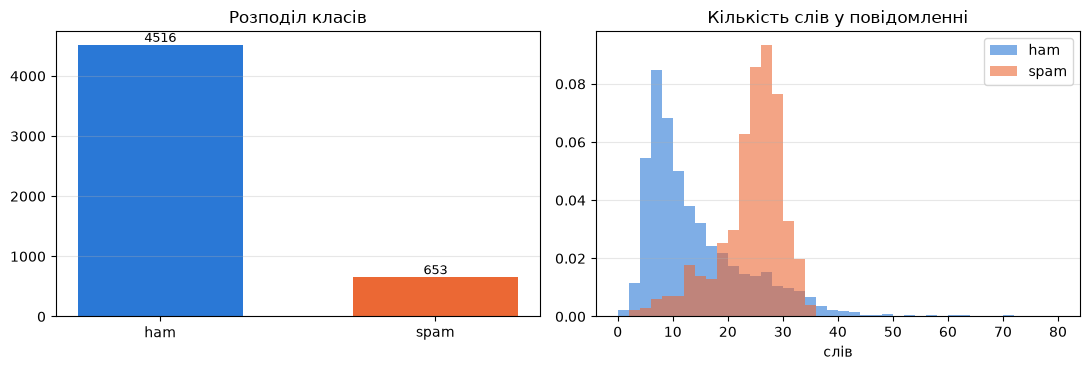

In [4]:
counts = df["label"].value_counts()
print(counts)
print((counts / counts.sum()).round(3))

df["n_words"] = df["text"].str.split().str.len()
print(df.groupby("label")["n_words"].describe()[["mean", "50%", "max"]])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].bar(counts.index, counts.values, color=[COLORS[c] for c in counts.index], width=0.6)
for i, v in enumerate(counts.values):
    axes[0].text(i, v, str(v), ha="center", va="bottom", fontsize=9)
axes[0].set_title("Розподіл класів")
for lbl in ["ham", "spam"]:
    axes[1].hist(df.loc[df.label == lbl, "n_words"], bins=40, range=(0, 80), density=True,
                 alpha=0.6, color=COLORS[lbl], label=lbl)
axes[1].set_title("Кількість слів у повідомленні")
axes[1].set_xlabel("слів")
axes[1].legend()
for ax in axes:
    ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## Попередня обробка


- html: спочатку html.unescape, бо плейсхолдери в датасеті екрановані (&lt;#&gt; це <#>, так
  замасковані числа в частині ham-повідомлень), потім прибираю все в кутових дужках;
- нижній регістр, все крім літер і цифр замінюю на пробіл. Цифри лишаю: номери телефонів,
  суми і коди на кшталт "150p" це сильні ознаки спаму. Посилання і email теж лишаю, з тієї ж
  причини (www. є у 83 спамах і в 1 ham), від них залишаться токени www, com, net;
- лематизація spaCy (going -> go, prizes -> prize, claimed -> claim), щоб форми одного слова
  стали однією ознакою;
- стоп-слова nltk без негацій, як у лекції. Тут це важливо не через "not", а через "won":
  у списку nltk він лежить як шматок від "won't", а в SMS це "you have won", маркер спаму;
- словник скорочень з лекції не потрібен: після заміни апострофа на пробіл шматки s, t, m,
  ll, ve, re вже є у стоп-списку nltk і випадають самі. Однолітерні токени не викидаю,
  бо "u", "n", "2", "4" у SMS це повноцінні слова.

Стоп-слова прибираю, як вимагає завдання, хоч серед них є "your", "you", "now", які для
спаму інформативні.

In [5]:
negations = {
    "aren", "aren't", "couldn", "couldn't", "didn", "didn't", "doesn", "doesn't", "don", "don't",
    "hadn", "hadn't", "hasn", "hasn't", "haven", "haven't", "isn", "isn't", "mightn", "mightn't",
    "mustn", "mustn't", "needn", "needn't", "no", "nor", "not", "shan", "shan't", "shouldn",
    "shouldn't", "wasn", "wasn't", "weren", "weren't", "won", "won't", "wouldn", "wouldn't",
}
stop_words = set(stopwords.words("english")) - negations
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def normalize_text(text):
    text = html.unescape(text)
    text = re.sub(r"<[^>]*>", " ", text)
    return re.sub(r"[^a-z0-9\s]", " ", text.lower())

# лематизую один раз для всього датасету, стоп-слова прибираю вже з лем
docs = nlp.pipe(df["text"].map(normalize_text), batch_size=256)
df["lemmas"] = [" ".join(t.lemma_.lower() for t in doc if not t.is_space) for doc in docs]
df["clean"] = df["lemmas"].map(lambda s: " ".join(t for t in s.split() if t not in stop_words))

examples = pd.concat([df[df.label == "spam"].head(2), df[df.label == "ham"].head(2),
                      df[df.text.str.contains("&lt;#&gt;")].head(1)])
for _, row in examples.iterrows():
    print(f"[{row.label}] {row.text}\n    -> {row.clean}")
print("\nпорожніх після очистки:", (df["clean"] == "").sum())

[spam] Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
    -> free entry 2 wkly comp win fa cup final tkts 21st may 2005 text fa 87121 receive entry question std txt rate c apply 08452810075over18
[spam] FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcv
    -> freemsg hey darle 3 week no word back like fun still tb ok xxx std chgs send 1 50 rcv
[ham] Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
    -> go jurong point crazy available bugis n great world la e buffet cine get amore wat
[ham] Ok lar... Joking wif u oni...
    -> ok lar joke wif u oni
[ham] Great! I hope you like your man well endowed. I am  &lt;#&gt;  inches...
    -> great hope like man well endow inch

порожніх після очистки: 6


## Розбиття на навчальну і валідаційну вибірки

80/20 зі стратифікацією, щоб частка спаму в обох частинах була однакова. Розбиваю до будь-якого
fit: словник векторизаторів і IDF рахуються тільки на train, валідація лише трансформується.

In [6]:
y = (df["label"] == "spam").astype(int).values
X_train_text, X_val_text, y_train, y_val = train_test_split(
    df["clean"], y, test_size=0.2, stratify=y, random_state=SEED)

print("train:", len(X_train_text), " val:", len(X_val_text))
print("частка спаму: train", y_train.mean().round(3), " val", y_val.mean().round(3))

train: 4135  val: 1034
частка спаму: train 0.126  val 0.127


## BoW і TF-IDF

BoW: кожна ознака це кількість входжень слова в повідомлення. TF-IDF множить цю
кількість на log-вагу, яка тим менша, чим у більшій частці документів трапляється слово:
часті в усьому корпусі слова притискаються, специфічні для документа виділяються.

In [7]:
bow = CountVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)

X_train_bow = bow.fit_transform(X_train_text)
X_val_bow = bow.transform(X_val_text)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf = tfidf.transform(X_val_text)

print("BoW:   ", X_train_bow.shape, X_val_bow.shape)
print("TF-IDF:", X_train_tfidf.shape, X_val_tfidf.shape)
print(f"ненульових елементів у матриці: {X_train_bow.nnz / np.prod(X_train_bow.shape):.3%}")

BoW:    (4135, 5000) (1034, 5000)
TF-IDF: (4135, 5000) (1034, 5000)
ненульових елементів у матриці: 0.185%


In [8]:
# одне спам-повідомлення в обох представленнях: у BoW лічильники, у TF-IDF ті ж лічильники,
# помножені на IDF і нормовані по рядку (L2), тому рідкісні слова отримують більшу вагу
i = int(np.where(y_train == 1)[0][0])
print(X_train_text.iloc[i])

feats = tfidf.get_feature_names_out()
row_bow = X_train_bow[i].toarray().ravel()
row_tfidf = X_train_tfidf[i].toarray().ravel()
nz = np.where(row_bow > 0)[0]
pd.DataFrame({"ознака": feats[nz], "BoW": row_bow[nz], "IDF": tfidf.idf_[nz].round(2),
              "TF-IDF": row_tfidf[nz].round(3)}).sort_values("TF-IDF", ascending=False).head(12)

18 day euro2004 kickoff u keep inform late news result daily unsubscribe send get euro stop 83222


,ознака,BoW,IDF,TF-IDF
16,stop 83222,1,8.23,0.289
4,euro,1,8.23,0.289
14,send get,1,8.23,0.289
12,result daily,1,8.23,0.289
1,83222,1,8.23,0.289
5,euro2004,1,7.94,0.279
2,daily,1,7.72,0.271
11,result,1,7.38,0.259
7,inform,1,7.38,0.259
17,unsubscribe,1,6.62,0.233


## Попередньо навчені ембедінги: GloVe


In [9]:
glove = api.load("glove-wiki-gigaword-100")
print(glove.vectors.shape)

train_tokens = Counter(t for s in X_train_text for t in s.split())
covered = sum(c for t, c in train_tokens.items() if t in glove.key_to_index)
print(f"покриття токенів train: {covered / sum(train_tokens.values()):.3f}")
print(f"покриття унікальних слів: {np.mean([t in glove.key_to_index for t in train_tokens]):.3f}")
oov = [(t, c) for t, c in train_tokens.most_common() if t not in glove.key_to_index]
print("найчастіші OOV:", oov[:20])
print("сусіди 'prize':", [w for w, _ in glove.most_similar("prize", topn=6)])

(400000, 100)
покриття токенів train: 0.933
покриття унікальних слів: 0.743
найчастіші OOV: [('150p', 43), ('thanx', 27), ('150ppm', 23), ('aight', 23), ('frnd', 20), ('chikku', 16), ('08000930705', 14), ('86688', 14), ('freemsg', 13), ('oredi', 13), ('mayb', 12), ('8007', 12), ('suite342', 11), ('2lands', 11), ('pobox', 10), ('12hrs', 10), ('custcare', 9), ('boytoy', 9), ('txts', 9), ('congrat', 9)]
сусіди 'prize': ['nobel', 'prizes', 'award', 'awarded', 'winner', 'awards']


In [10]:
def text_to_vec(text, kv):
    vecs = [kv[t] for t in text.split() if t in kv.key_to_index]
    if not vecs:
        return np.zeros(kv.vector_size, dtype=np.float32)
    return np.mean(vecs, axis=0)

def texts_to_matrix(texts, kv):
    return np.vstack([text_to_vec(t, kv) for t in texts])

X_train_emb = texts_to_matrix(X_train_text, glove)
X_val_emb = texts_to_matrix(X_val_text, glove)
print(X_train_emb.shape, X_val_emb.shape)
print("нульових векторів у val:", int((np.abs(X_val_emb).sum(1) == 0).sum()))

(4135, 100) (1034, 100)
нульових векторів у val: 3


## Моделі

Логістична регресія на всіх трьох представленнях. Для розріджених BoW і TF-IDF. Для щільних 100-вимірних ембедінгів додаю StandardScaler: координати GloVe
мають різний масштаб, і без нього lbfgs збігається гірше.

## Метрики

Головна метрика AUC: якість ранжування спаму над ham незалежно від порогу. Рахую її по ймовірностях predict_proba, а не по мітках predict.

In [11]:
def evaluate(name, model, X_tr, X_va):
    model.fit(X_tr, y_train)
    if hasattr(model, "predict_proba"):
        score = model.predict_proba(X_va)[:, 1]
    else:
        score = model.decision_function(X_va)
    pred = model.predict(X_va)
    metrics = {"модель": name,
               "accuracy": accuracy_score(y_val, pred),
               "AUC": roc_auc_score(y_val, score),
               "precision_spam": precision_score(y_val, pred),
               "recall_spam": recall_score(y_val, pred),
               "F1_spam": f1_score(y_val, pred)}
    return metrics, score, pred

models = {
    "BoW + LR": LogisticRegression(max_iter=1000, random_state=SEED),
    "TF-IDF + LR": LogisticRegression(max_iter=1000, random_state=SEED),
    "GloVe + LR": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=SEED)),
}
features = {
    "BoW + LR": (X_train_bow, X_val_bow),
    "TF-IDF + LR": (X_train_tfidf, X_val_tfidf),
    "GloVe + LR": (X_train_emb, X_val_emb),
}

results, scores, preds = [], {}, {}
for name, model in models.items():
    m, scores[name], preds[name] = evaluate(name, model, *features[name])
    results.append(m)

print(f"бейзлайн 'усе ham': accuracy = {1 - y_val.mean():.3f}")
pd.DataFrame(results).set_index("модель").round(4)

бейзлайн 'усе ham': accuracy = 0.873


,accuracy,AUC,precision_spam,recall_spam,F1_spam
модель,,,,,
BoW + LR,0.9797,0.9900,0.9911,0.8473,0.9136
TF-IDF + LR,0.9671,0.9912,1.0000,0.7405,0.8509
GloVe + LR,0.9313,0.9670,0.7419,0.7023,0.7216


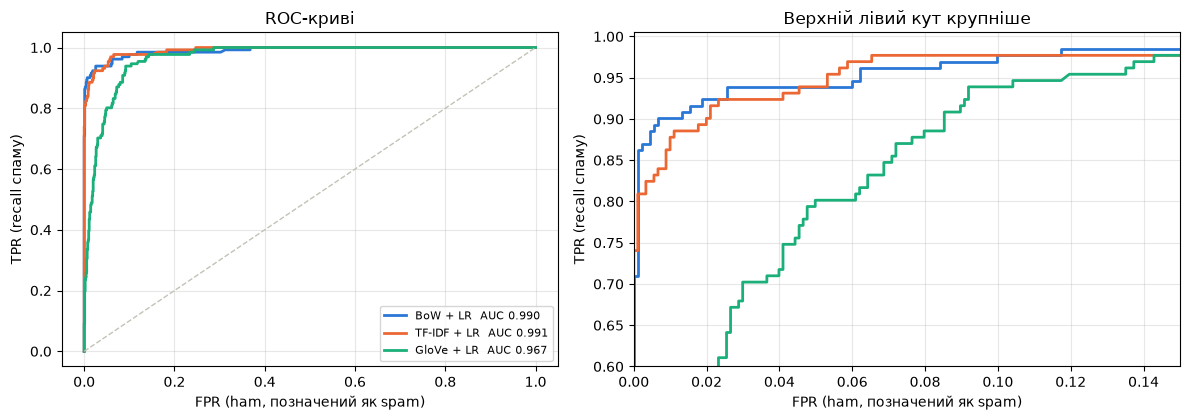

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), gridspec_kw={"width_ratios": [1, 1.1]})
for (name, score), color in zip(scores.items(), MODEL_COLORS):
    fpr, tpr, _ = roc_curve(y_val, score)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f"{name}  AUC {roc_auc_score(y_val, score):.3f}")
    axes[1].plot(fpr, tpr, color=color, lw=2)
for ax in axes:
    ax.plot([0, 1], [0, 1], "--", color="#c3c2b7", lw=1)
    ax.set_xlabel("FPR (ham, позначений як spam)")
    ax.set_ylabel("TPR (recall спаму)")
    ax.grid(alpha=0.3)
axes[0].set_title("ROC-криві")
axes[0].legend(fontsize=8, loc="lower right")
axes[1].set_xlim(0, 0.15)
axes[1].set_ylim(0.6, 1.005)
axes[1].set_title("Верхній лівий кут крупніше")
plt.tight_layout()
plt.show()

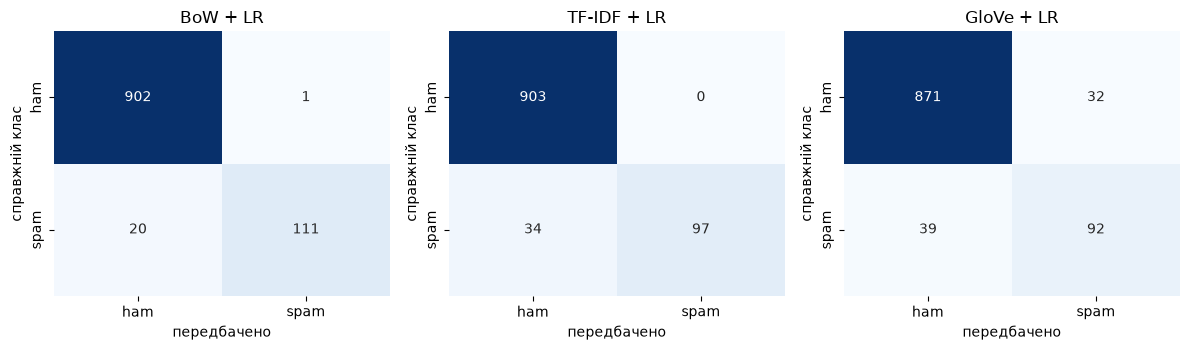

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, (name, pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_val, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
    ax.set_title(name)
    ax.set_xlabel("передбачено")
    ax.set_ylabel("справжній клас")
plt.tight_layout()
plt.show()

## Інтерпретація

Коефіцієнти логістичної регресії на TF-IDF читаються напряму: додатний коефіцієнт тягне
прогноз до спаму, від'ємний до ham. Для ембедінгів такого списку немає, ознаки це координати
в просторі GloVe і окремо взяті не мають сенсу. Тому для них дивлюся на помилки: які
повідомлення вони класифікують інакше, ніж TF-IDF.

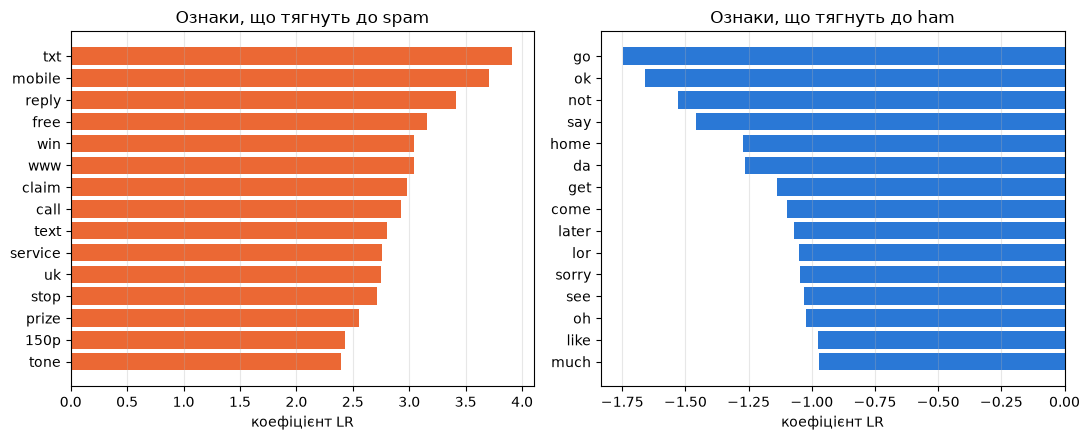

In [14]:
coef = models["TF-IDF + LR"].coef_.ravel()
top_spam = np.argsort(coef)[-15:]
top_ham = np.argsort(coef)[:15][::-1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].barh(feats[top_spam], coef[top_spam], color=COLORS["spam"])
axes[0].set_title("Ознаки, що тягнуть до spam")
axes[1].barh(feats[top_ham], coef[top_ham], color=COLORS["ham"])
axes[1].set_title("Ознаки, що тягнуть до ham")
for ax in axes:
    ax.grid(alpha=0.3, axis="x")
    ax.set_xlabel("коефіцієнт LR")
plt.tight_layout()
plt.show()

In [15]:
val_df = pd.DataFrame({"text": df.loc[X_val_text.index, "text"].values, "y": y_val,
                       "tfidf": preds["TF-IDF + LR"], "glove": preds["GloVe + LR"]})
pd.set_option("display.max_colwidth", 130)

print("TF-IDF правильно, GloVe помилився:", ((val_df.tfidf == val_df.y) & (val_df.glove != val_df.y)).sum())
display(val_df[(val_df.tfidf == val_df.y) & (val_df.glove != val_df.y)][["y", "text"]].head(6))
print("GloVe правильно, TF-IDF помилився:", ((val_df.glove == val_df.y) & (val_df.tfidf != val_df.y)).sum())
display(val_df[(val_df.glove == val_df.y) & (val_df.tfidf != val_df.y)][["y", "text"]].head(6))
print("обидва помилилися:", ((val_df.glove != val_df.y) & (val_df.tfidf != val_df.y)).sum())
display(val_df[(val_df.glove != val_df.y) & (val_df.tfidf != val_df.y)][["y", "text"]].head(6))

TF-IDF правильно, GloVe помилився: 50


,y,text
55,1,I am hot n horny and willing I live local to you - text a reply to hear strt back from me 150p per msg Netcollex LtdHelpDesk: ...
71,1,Your unique user ID is 1172. For removal send STOP to 87239 customer services 08708034412
90,0,En chikku nange bakra msg kalstiya..then had tea/coffee?
98,0,May b approve panalam...but it should have more posts..
110,0,i dnt wnt to tlk wid u
127,0,I'm reaching home in 5 min.


GloVe правильно, TF-IDF помилився: 13


,y,text
79,1,Thanks for the Vote. Now sing along with the stars with Karaoke on your mobile. For a FREE link just reply with SING now.
95,1,Want explicit SEX in 30 secs? Ring 02073162414 now! Costs 20p/min Gsex POBOX 2667 WC1N 3XX
112,1,Send a logo 2 ur lover - 2 names joined by a heart. Txt LOVE NAME1 NAME2 MOBNO eg LOVE ADAM EVE 07123456789 to 87077 Yahoo! PO...
163,1,"SMSSERVICES. for yourinclusive text credits, pls goto www.comuk.net login= 3qxj9 unsubscribe with STOP, no extra charge. help ..."
174,1,"TheMob>Hit the link to get a premium Pink Panther game, the new no. 1 from Sugababes, a crazy Zebra animation or a badass Hood..."
205,1,As a registered optin subscriber ur draw 4 å£100 gift voucher will be entered on receipt of a correct ans to 80062 Whats No1 i...


обидва помилилися: 21


,y,text
105,1,You will recieve your tone within the next 24hrs. For Terms and conditions please see Channel U Teletext Pg 750
121,1,"WELL DONE! Your 4* Costa Del Sol Holiday or å£5000 await collection. Call 09050090044 Now toClaim. SAE, TCs, POBox334, Stockpo..."
125,1,"Congrats! 1 year special cinema pass for 2 is yours. call 09061209465 now! C Suprman V, Matrix3, StarWars3, etc all 4 FREE! bx..."
166,1,8007 25p 4 Alfie Moon's Children in Need song on ur mob. Tell ur m8s. Txt TONE CHARITY to 8007 for nokias or POLY CHARITY for ...
168,1,Hi if ur lookin 4 saucy daytime fun wiv busty married woman Am free all next week Chat now 2 sort time 09099726429 JANINExx Ca...
223,1,Guess what! Somebody you know secretly fancies you! Wanna find out who it is? Give us a call on 09065394973 from Landline DATE...


## Аналіз результатів

За AUC BoW і TF-IDF практично рівні (0.990 і 0.991), GloVe помітно позаду (0.967). За accuracy
і F1 при порозі 0.5 різниця більша: BoW 0.980 / 0.91, TF-IDF 0.967 / 0.85, GloVe 0.931 / 0.72.
Розрив між AUC і F1 у TF-IDF не суперечність: рядки TF-IDF нормовані по L2, значення ознак
малі, і при стандартній регуляризації C=1 логіти виходять стриманими, тож частина спаму
отримує ймовірність трохи нижче 0.5 (34 пропущених проти 20 у BoW, зате жодного хибного спаму).
Порядок повідомлень при цьому правильний, що і показує AUC. Зсув порогу або
class_weight="balanced" (розділ нижче) піднімає recall до 0.90.

BoW і TF-IDF майже не дають хибних спрацювань (1 і 0 ham з 903), а пропускають спам, написаний
без типових маркерів. GloVe навпаки: 32 ham позначені як спам, precision по спаму лише 0.74.
Усереднений вектор розмиває сигнал: "call 09061701461 now" і "call me when u get home" в
просторі GloVe лежать поруч, бо номер телефону OOV і випадає, а решта слів побутова. Приклади
вище це підтверджують: GloVe помиляється на коротких розмовних ham ("I'm reaching home in 5
min", "i dnt wnt to tlk wid u") і на сленгу, якого немає у Вікіпедії. Зате він ловить частину
спаму, де конкретні токени рідкісні для train-словника ("SMSSERVICES", "premium Pink Panther
game"): схоже, спрацьовує семантика слів на кшталт premium, subscriber, voucher.

Найсильніші ознаки TF-IDF читаються як портрет спаму: txt, mobile, reply, free, win, www,
claim, call, prize, 150p. Ham тримається на розмовних go, ok, say, home, come, later, sorry.
Серед ham-ознак є і not: негації лишилися в тексті, а в цьому корпусі not стоїть у 8% ham і
лише в 3% спаму, реклама рідко щось заперечує.

Переваги і недоліки підходів:

- BoW. Найпростіший і прозорий, сильний на коротких текстах з чіткими маркерами. Мінуси:
  словник фіксований, нових слів не знає, довжина тексту напряму впливає на масштаб ознак,
  біграми роздувають розмірність.
- TF-IDF. Ті ж плюси, а ще приглушує часті слова і нормує довжину, тому ранжує не гірше при
  меншій кількості хибних спрацювань. Мінуси ті ж, і за замовчуванням гірше калібрований,
  поріг варто підбирати.
- Усереднені GloVe. Щільний 100-вимірний вектор, знає синонімію і переноситься на слова, яких
  у train не було. Мінуси: губить порядок слів і OOV-токени (7% токенів тут, включно з номерами
  і сленгом), одне середнє на все повідомлення розмиває сигнал, і лінійна модель на ньому слабка.

## Вдосконалення

Кілька дешевих варіантів: інші класифікатори на тих самих ознаках, тільки уніграми замість
уні+біграм, символьні n-грами TF-IDF (ловлять частини слів, тому "thanx", "frnd", "150p"
перестають бути унікальними токенами), перевірка, чи шкодить видалення стоп-слів, GloVe,
навчений на твітах (ближчий за стилем до SMS, файл близько 400 МБ), і Word2Vec, навчений
з нуля на train-корпусі, як у лекції.

In [16]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

def lr(**kw):
    return LogisticRegression(max_iter=1000, random_state=SEED, **kw)

extra = []
extra.append(evaluate("TF-IDF + MultinomialNB", MultinomialNB(), X_train_tfidf, X_val_tfidf)[0])
extra.append(evaluate("TF-IDF + LinearSVC", LinearSVC(random_state=SEED), X_train_tfidf, X_val_tfidf)[0])
extra.append(evaluate("TF-IDF + RandomForest", RandomForestClassifier(300, n_jobs=-1, random_state=SEED),
                      X_train_tfidf, X_val_tfidf)[0])
extra.append(evaluate("TF-IDF + LR balanced", lr(class_weight="balanced"), X_train_tfidf, X_val_tfidf)[0])
extra.append(evaluate("GloVe + RandomForest", RandomForestClassifier(300, n_jobs=-1, random_state=SEED),
                      X_train_emb, X_val_emb)[0])
extra.append(evaluate("GloVe + MLP", make_pipeline(StandardScaler(), MLPClassifier((128,), max_iter=500, random_state=SEED)),
                      X_train_emb, X_val_emb)[0])
pd.DataFrame(extra).set_index("модель").round(4)

,accuracy,AUC,precision_spam,recall_spam,F1_spam
модель,,,,,
TF-IDF + MultinomialNB,0.9671,0.9850,0.9899,0.7481,0.8522
TF-IDF + LinearSVC,0.9807,0.9925,0.9664,0.8779,0.9200
TF-IDF + RandomForest,0.9768,0.9867,0.9908,0.8244,0.9000
TF-IDF + LR balanced,0.9729,0.9911,0.8872,0.9008,0.8939
GloVe + RandomForest,0.9574,0.9674,0.9888,0.6718,0.8000
GloVe + MLP,0.9710,0.9872,0.8976,0.8702,0.8837


In [17]:
# тільки уніграми
tfidf_uni = TfidfVectorizer(max_features=5000, min_df=2)
extra.append(evaluate("TF-IDF (1,1) + LR", lr(), tfidf_uni.fit_transform(X_train_text), tfidf_uni.transform(X_val_text))[0])

# символьні n-грами
tfidf_char = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), min_df=2, max_features=30000)
X_train_char = tfidf_char.fit_transform(X_train_text)
X_val_char = tfidf_char.transform(X_val_text)
print("char n-grams:", X_train_char.shape)
extra.append(evaluate("TF-IDF char(2-5) + LR", lr(), X_train_char, X_val_char)[0])

# без видалення стоп-слів (ті ж леми, стоп-слова лишаються)
X_train_raw = df.loc[X_train_text.index, "lemmas"]
X_val_raw = df.loc[X_val_text.index, "lemmas"]
tfidf_all = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
extra.append(evaluate("TF-IDF зі стоп-словами + LR", lr(),
                      tfidf_all.fit_transform(X_train_raw), tfidf_all.transform(X_val_raw))[0])

# GloVe з твітів
glove_tw = api.load("glove-twitter-100")
covered = sum(c for t, c in train_tokens.items() if t in glove_tw.key_to_index)
print(f"покриття токенів twitter-GloVe: {covered / sum(train_tokens.values()):.3f}")
extra.append(evaluate("GloVe-twitter + LR", make_pipeline(StandardScaler(), lr()),
                      texts_to_matrix(X_train_text, glove_tw), texts_to_matrix(X_val_text, glove_tw))[0])

# Word2Vec з нуля на train-корпусі: min_count менший, ніж у лекції, бо корпус маленький;
# workers=1 заради відтворюваності
corpus = [s.split() for s in X_train_text]
w2v = Word2Vec(corpus, vector_size=100, window=5, min_count=2, epochs=30, seed=SEED, workers=1)
print("словник w2v:", len(w2v.wv.key_to_index),
      " сусіди 'prize':", [w for w, _ in w2v.wv.most_similar("prize", topn=5)])
extra.append(evaluate("Word2Vec з нуля + LR", make_pipeline(StandardScaler(), lr()),
                      texts_to_matrix(X_train_text, w2v.wv), texts_to_matrix(X_val_text, w2v.wv))[0])

all_results = pd.DataFrame(results + extra).set_index("модель").round(4).sort_values("AUC", ascending=False)
all_results

char n-grams: (4135, 22151)


покриття токенів twitter-GloVe: 0.897


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


словник w2v: 2874  сусіди 'prize': ['bonus', 'caller', '02', '06', 'guarantee']


,accuracy,AUC,precision_spam,recall_spam,F1_spam
модель,,,,,
TF-IDF char(2-5) + LR,0.9787,0.9973,1.0000,0.8321,0.9083
TF-IDF + LinearSVC,0.9807,0.9925,0.9664,0.8779,0.9200
"TF-IDF (1,1) + LR",0.9700,0.9913,1.0000,0.7634,0.8658
TF-IDF + LR,0.9671,0.9912,1.0000,0.7405,0.8509
TF-IDF + LR balanced,0.9729,0.9911,0.8872,0.9008,0.8939
BoW + LR,0.9797,0.9900,0.9911,0.8473,0.9136
Word2Vec з нуля + LR,0.9720,0.9899,0.9180,0.8550,0.8854
TF-IDF зі стоп-словами + LR,0.9691,0.9889,1.0000,0.7557,0.8609
GloVe + MLP,0.9710,0.9872,0.8976,0.8702,0.8837


## Висновки

- Для цієї задачі методи на основі підрахунку виграють: BoW + LR і TF-IDF + LR дають AUC 0.990
  і 0.991, усереднені GloVe + LR 0.967. Спам у SMS видають конкретні токени (txt, free, claim,
  call, номери, 150p), лічильники слів ловлять їх напряму, а середнє ембедінгів їх розмиває.
- Найкраще ранжування дали символьні n-грами TF-IDF (AUC 0.997, жодного хибного спаму): вони
  стійкі до "thanx", "frnd", "txts" і бачать структуру номерів, яку словесні токени втрачають
  через min_df. Найкращий F1 у LinearSVC на TF-IDF (0.92). Біграми нічого не додали: самі
  уніграми дають той самий AUC 0.991.
- Word2Vec, навчений з нуля на 4 тис. SMS, обійшов GloVe з Вікіпедії (AUC 0.990 проти 0.967):
  словник у нього маленький (2874 слова), зате свій, з "150p", "txt", кодами, і сусіди "prize"
  в ньому bonus, caller, guarantee. Для такої задачі відповідність домену важить більше за
  якість векторів.
- Класифікатор для ембедінгів має значення: MLP на тих самих GloVe-векторах піднімає AUC з
  0.967 до 0.987 і recall до 0.87, тобто слабке місце частково в лінійності моделі. GloVe з
  твітів дав невелику надбавку (AUC 0.970), хоча покриття токенів у нього нижче (0.90 проти
  0.93), бо числа там замінені спецтокеном.
- Видалення стоп-слів практично нічого не змінило (AUC 0.991 проти 0.989 зі стоп-словами),
  хоч "your", "you", "now" і є маркерами спаму: решта лексики це компенсує.
- Орієнтовні 82-85% accuracy із завдання для цього датасету занизькі: константний прогноз
  "ham" уже дає 0.873, а всі моделі вище 0.93. Порівнювати варто по AUC і F1 для спаму.